# Module 3 Homework: Chapter 4 Exercises

## Ryan Waterman
## 7/25/25

## Problem 13

This question should be answered using the Weekly data set, which is part of the ISLP package. This data is similar in nature to the Smarket data from this chapter’s lab, except that it contains 1, 089 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

The dataset variables are as follows:

Year: The year that the observation was recorded

Lag1: Percentage return for previous week

Lag2: Percentage return for 2 weeks previous

Lag3: Percentage return for 3 weeks previous

Lag4: Percentage return for 4 weeks previous

Lag5: Percentage return for 5 weeks previous

Volume: Volume of shares traded (average number of daily shares traded in billions)

Today: Percentage return for this week

Direction: A factor with levels ‘Down’ and ‘Up’ indicating whether the market had a positive or negative return on a given week.

In [39]:
# Import the ISLP load_data function
from ISLP import load_data
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [40]:
weekly = load_data('Weekly')

In [41]:
weekly.head(5)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


## Part A

Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

**First, I want to use the describe function to get a better understanding of the numerical data.**

In [42]:
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


**My initial observation is that the mean return across all time domains in the dataset is ~0.15% on average. This is what I would expect, as the common trope for the S&P500 is that it returns about 9% YoY on average. When 0.15% week over week returns are annualized, that equates to 7.8% average YoY return.**

**Next, I am interested in the correlation matrix for the quantitative columns in the dataset.**

In [43]:
quant = weekly.describe().columns
weekly[quant].corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


**It is hard to discern any meaningful insights from the correlation matrix alone. Volume and year are the only variables with a correlation coefficient greater than 0.1, implying that most of the variables are weakly correlated. A scatter matrix will aid in my understanding of this data.**

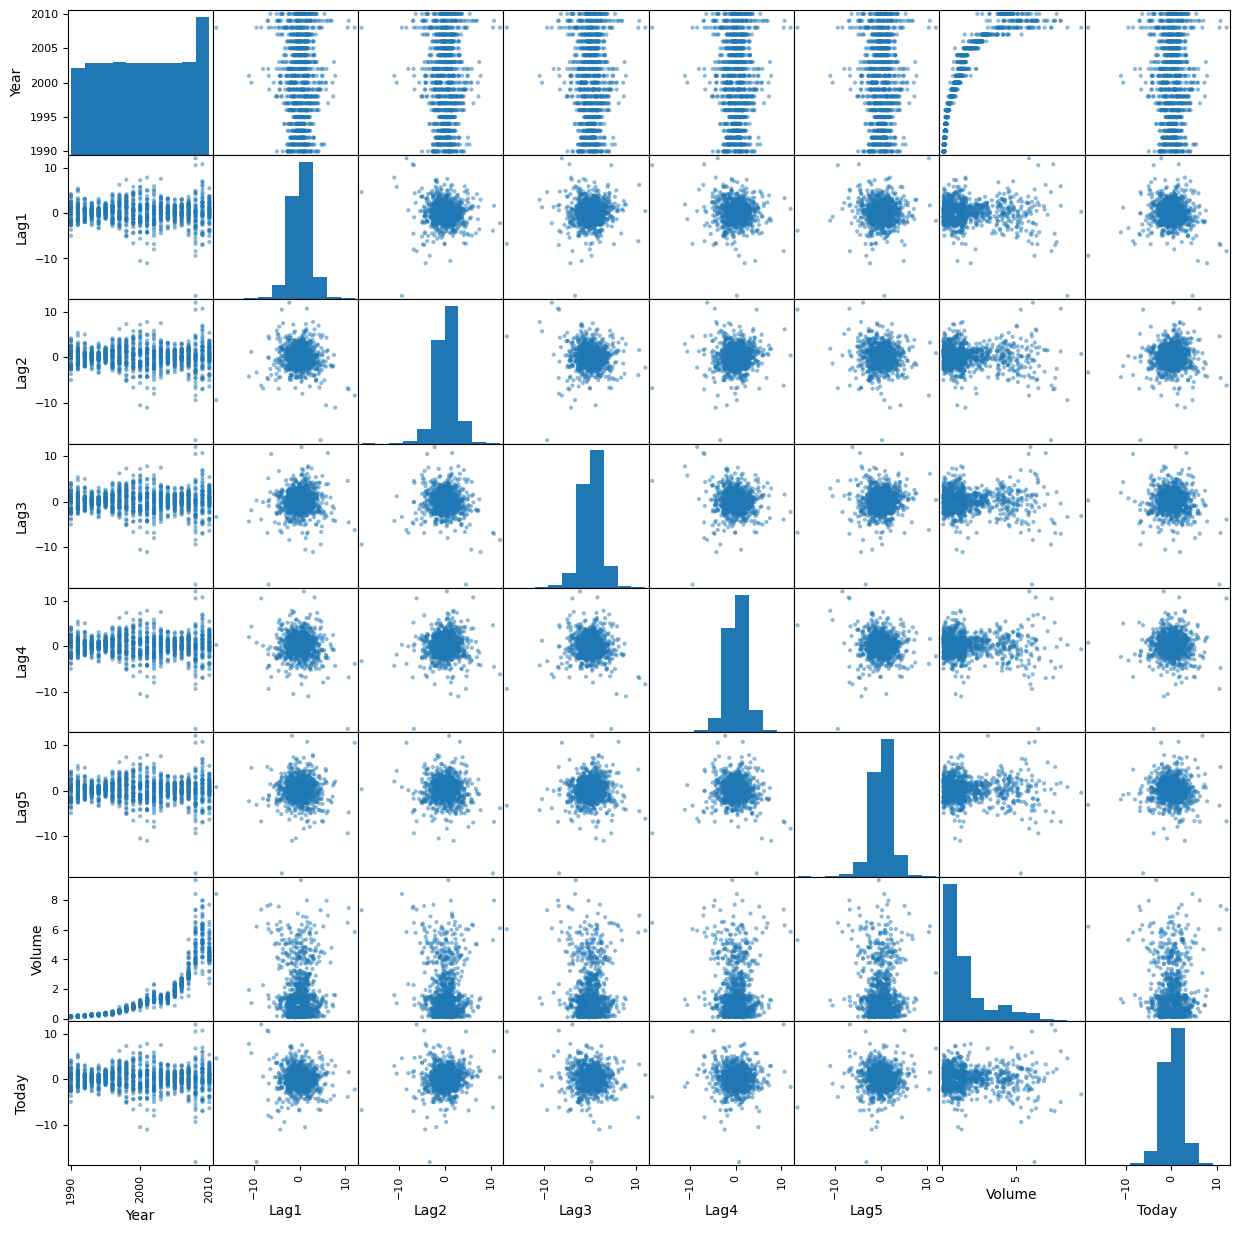

In [44]:
pd.plotting.scatter_matrix(weekly, figsize=(15,15));

**The scatter matrix provides more insight for the relationships in the dataset.**

1. **Volume and Year are related exponentially. Interestingly, the market collapse and instability from 2008-2010 is clearly evident in this relationship, resulting in a decrease in volume.**
2. **Year versus Today and the Lag variables describe market volatility. The greater the distribution of percent return in a given year, the more the market has fluctuated. This is an indication of market instability. When this relationship is compared to Year vs. Volume, it becomes evident that Volume is an influencial factor in market volatility. Greater market volatility is correlated with periods of greater volume variance.**
3. **All of the Lag variables, as well as the Today variable, are normally distributed. The mean value of ~0.15% for these variables is a result of the greater distribution of positive percent returns, seen in each of the histogram plots.**
4. **The Volume histogram plot exibits an exponential distribution, implying that increasingly greater volumes are exponentially more rare.**

## Part B

Use the full data set to perform a logistic regression with Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [45]:
import statsmodels.api as sm

In [46]:
# Convert direction to a binary value
weekly['Direction'].replace({'Up':1, 'Down':0}, inplace=True)

In [47]:
X = weekly[['Lag1','Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y = weekly[['Direction']]

logit_model = sm.Logit(y, X).fit()

logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.686896
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1083
Method:                           MLE   Df Model:                            5
Date:                Sun, 27 Jul 2025   Pseudo R-squ.:               9.505e-05
Time:                        17:47:53   Log-Likelihood:                -748.03
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.9996
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Lag1          -0.0327      0.026     -1.250      0.211      -0.084       0.019
Lag2           0.0682      0.027      2.556      0.011       0.016       0.120
Lag3          -0.0081      0.026     -0.306      0.759      -0.060       0.044
Lag4          -0.0194      0.026     -0.740      0.459      -0.071       0.032
Lag5          -0.0069      0.026     -0.261      0.794      -0.058       0.045
Volume         0.0569      0.027      2.125      0.034       0.004       0.109
==============================================================================
"""

**The model output indicates that the Lag and Volume variables are poor predictors of direction. See the model parameter breakdown, below:**

1. A Psuedo R-squared value of 9.505e-05 proves the model does not explain the variation in direction. 
2. A Log-Likelihood of -748.03 indicates the model does not explain the observed data. This is a metric of how well the model fits the data, with 0 being a perfect fit.
3. LL-Null represents the Log-Likelihood of a model with no predictors, and serves as a baseline to compare the Log-Likelihood of the model against. The model produced a nearly identical Log Likelihood to LL-Null (-748.03 vs. -748.10, respectively), therefore the model with predictors does not fit the data any better than a model without predictors at all.   
4. LLR, or the Log-Likelihood Ratio test, described whether the model is better at predicting Direction than the LL-Null model. A p-value of 0.9996 indicates the model does not predict Direction any better than the null model.

**The statistical significance of the predictors is evaluated, below:**

1. Lag1 - Not statistically significant (P>|z| = 0.211)
2. Lag2 - Statistically significant (P>|z| = 0.011)
3. Lag3 - Not statistically significant (P>|z| = 0.759)
4. Lag4 - Not statistically significant (P>|z| = 0.459)
5. Lag5 - Not statistically significant (P>|z| = 0.794)
6. Volume - Statistically significant (P>|z| = 0.034)

## Part C

Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

**Get the prediction table for the model.**

In [49]:
logit_model.pred_table(threshold=0.5)

array([[172., 312.],
       [178., 427.]])

**I couldn't find any information on what array indices from the pred_table result represented each prediction configurations, so I am going to create the confusion matrix from scratch to be sure.**

In [50]:
predictions = logit_model.predict()

reclassified_predictions = []

for pred in predictions:
    if pred >= 0.5:
        reclassified_predictions.append(1)
    else:
        reclassified_predictions.append(0)

confusion_matrix = {
    'true_up':0,
    'false_up':0,
    'true_down':0,
    'false_down':0
}

for i, dir in enumerate(weekly['Direction']):
    if reclassified_predictions[i] == 1 and dir == 0:
        confusion_matrix['false_up']+=1
    elif reclassified_predictions[i] == 1 and dir == 1:
        confusion_matrix['true_up']+=1
    elif reclassified_predictions[i] == 0 and dir == 1:
        confusion_matrix['false_down']+=1
    elif reclassified_predictions[i] == 0 and dir == 0:
        confusion_matrix['true_down'] += 1

confusion_matrix    


{'true_up': 427, 'false_up': 312, 'true_down': 172, 'false_down': 178}

In [51]:
accuracy_score(weekly['Direction'], reclassified_predictions)

0.5500459136822773

**Overall fraction of correct predictions: 55%**

**This result is expected based on the model statistics. Based on the accuracy value, the model is essentially randomly guessing.**

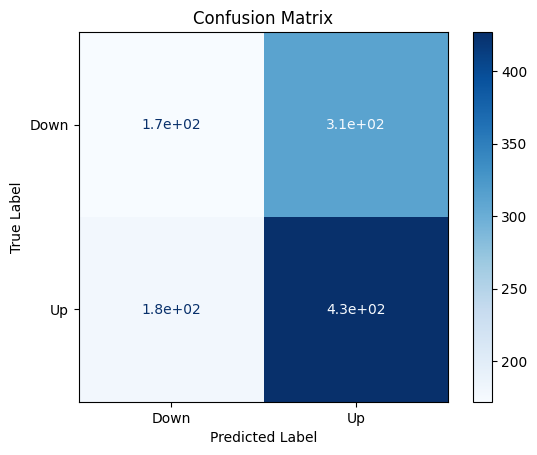

In [52]:
cm = ConfusionMatrixDisplay(
    confusion_matrix=logit_model.pred_table(threshold=0.5),
    display_labels=['Down', 'Up']
    )

cm.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Based on these results, I am curious about the distribution of Up and Down direction in the dataset. Let's check that.**

In [53]:
print(f'Number of Up values: {len(weekly[weekly['Direction']==1])}')
print(f'Number of Down values: {len(weekly[weekly['Direction']==0])}')
print(f'Percent Up: {(len(weekly[weekly['Direction']==1])/len(weekly))*100}')
print(f'Percent Down: {(len(weekly[weekly['Direction']==0])/len(weekly))*100}')

Number of Up values: 605
Number of Down values: 484
Percent Up: 55.55555555555556
Percent Down: 44.44444444444444


**Okay, so the data has a slight imbalance toward the Up direction. This may help to explain the disproportionate number of 'Up' predictions made by the model. Next, evaluate the ditribution of the predictions to see if it is similar.**

In [54]:
print(f'Number of Up Predictions: {confusion_matrix['true_up'] + confusion_matrix['false_up']}')
print(f'Number of Down Predictions: {confusion_matrix['true_down'] + confusion_matrix['false_down']}')
print(f'Percent Up Predictions: {((confusion_matrix['true_up'] + confusion_matrix['false_up'])/len(weekly))*100}')
print(f'Percent Down Predictions: {((confusion_matrix['true_down'] + confusion_matrix['false_down'])/len(weekly))*100}')

Number of Up Predictions: 739
Number of Down Predictions: 350
Percent Up Predictions: 67.86042240587695
Percent Down Predictions: 32.13957759412305


**Between the confusion matrix and the prediction distribution, it is clear that the model is disproporionately predicting the 'Up' direction. The most accurately predictied direction was 'Up', with 427 correct predictions and 178 incorrect predictions. The least accurately predicted variable was 'Down', with 172 correct predictions and 312 incorrect predictions. My hypothesis is the model learned to predict 'Up' due to the imbalance of true 'Up' directions present in the training set. When looking back at the statistically significant predictors from the model training, I further believe that Lag2 and Volume are correlated with upward trends, biasing the model further toward 'Up' predictions.**

## Part D

Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

In [55]:
filtered_weekly = weekly[(weekly['Year']>=1990) & (weekly['Year']<=2008)]

X = filtered_weekly[['Lag2']]
y = filtered_weekly[['Direction']]

logit_model2 = sm.Logit(y, X).fit()

logit_model2.summary()

Optimization terminated successfully.
         Current function value: 0.690654
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Direction   No. Observations:                  985
Model:                          Logit   Df Residuals:                      984
Method:                           MLE   Df Model:                            0
Date:                Sun, 27 Jul 2025   Pseudo R-squ.:               -0.004340
Time:                        17:47:53   Log-Likelihood:                -680.29
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                       nan
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Lag2           0.0629      0.029      2.192      0.028       0.007       0.119
==============================================================================
"""

**The model output indicates that the Lag2 variable is a poor predictor of direction. See the model parameter breakdown, below:**

1. A Psuedo R-squared value of -0.004340 proves the model does not explain the variation in direction. 
2. A Log-Likelihood of -680.29 indicates the model does not explain the observed data. This is a metric of how well the model fits the data, with 0 being a perfect fit.
3. LL-Null represents the Log-Likelihood of a model with no predictors, and serves as a baseline to compare the Log-Likelihood of the model against. The model produced a Log Likelihood value that is worse than LL-Null (-680.29 vs. -677.35, respectively), therefore the model with Lag2 as a predictor fits the data worse than a model without predictors at all.   
4. LLR, or the Log-Likelihood Ratio test, described whether the model is better at predicting Direction than the LL-Null model. A p-value of nan likely results from a computational error that arises from Log-Liklihood being less than LL-Null 

**The statistical significance of the Lag2 predictor is evaluated, below:**

1. Lag2 - Statistically significant (P>|z| = 0.028)


**Setting up a ModelEvaluator class to handle the redundant model eval process that will occur throughout the rest of the assignment.**

In [56]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

class ModelEvaluator():
    def __init__(self, name):
        self.name = name
    
    def fit_model(self, X, y):
        if self.name == 'Logistic Regression':
            import statsmodels.api as sm
            self.model = sm.Logit(y, X).fit()
        elif self.name == 'LDA':
            from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
            self.model = LinearDiscriminantAnalysis().fit(X, y)
        elif self.name == 'QDA':
            from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
            self.model = QuadraticDiscriminantAnalysis().fit(X, y)
        elif self.name == 'KNN':
            from sklearn.neighbors import KNeighborsClassifier
            n_neighbors = int(input('Enter the number of neighbors:'))
            print(f'Number of neighbors selected: {n_neighbors}')
            self.model = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
        elif self.name == 'Naive Bayes':
            from sklearn.naive_bayes import CategoricalNB
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(X)
            self.model = CategoricalNB(min_categories=2).fit(X_scaled,y)

    def eval_model(self, novel_X, novel_y, labels):
        self.novel_x = novel_X
        self.novel_y = novel_y
        self.labels = labels

        if len(self.novel_x.shape)>1:
            shape = (self.novel_x.shape[0], self.novel_x.shape[1])
        else:
            shape = (-1,1)

        if self.name == 'Naive Bayes':
            from sklearn.preprocessing import MinMaxScaler
            scaler = MinMaxScaler()
            X_scaled = scaler.fit_transform(np.array(novel_X).reshape(shape[0],shape[1]))
            predictions = self.model.predict(X_scaled.reshape(shape[0],shape[1]))
        else:
            predictions = self.model.predict(np.array(novel_X).reshape(shape[0],shape[1]))

        self.reclassified_predictions = []

        for pred in predictions:
            if pred >= 0.5:
                self.reclassified_predictions.append(1)
            else:
                self.reclassified_predictions.append(0)

        self.confusion_matrix = {
            'true_up':0,
            'false_up':0,
            'true_down':0,
            'false_down':0
        }

        for i, dir in enumerate(self.novel_y.values):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_up']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_up']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_down']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_down'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_down'], self.confusion_matrix['false_up']],
                                    [self.confusion_matrix['false_down'], self.confusion_matrix['true_up']]])

        self._plot_cm()
        self._describe_predictions()
        self._compute_accuracy()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_up'] + self.confusion_matrix['false_up']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_down'] + self.confusion_matrix['false_down']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_up'] + self.confusion_matrix['false_up'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_down'] + self.confusion_matrix['false_down'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    def _compute_accuracy(self):
        self.accuracy = accuracy_score(self.novel_y, self.reclassified_predictions)
        print(f'\nAccuracy: {self.accuracy}')


**Now, filter the weekly dataset to extract the novel data.**

In [57]:
novel_data = weekly[(weekly['Year']>2008)]
novel_X = novel_data['Lag2']
novel_y = novel_data['Direction']
labels = ['Down', 'Up']

Optimization terminated successfully.
         Current function value: 0.690654
         Iterations 4


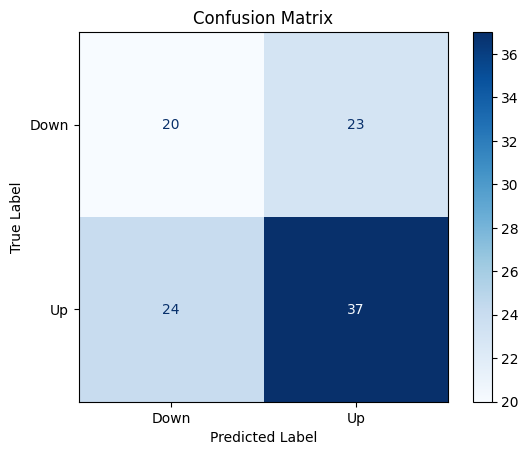

Number of Up Predictions: 60
Number of Down Predictions: 44
Percent Up Predictions: 57.692307692307686
Percent Down Predictions: 42.30769230769231

Accuracy: 0.5480769230769231


In [58]:
logit_model2 = ModelEvaluator('Logistic Regression')
logit_model2.fit_model(X,y)
logit_model2.eval_model(novel_X, novel_y, labels)

**Overall fraction of correct predictions: 54.8%**

**This result is expected based on the model statistics. Based on the accuracy value, the model is essentially randomly guessing.**

**Between the confusion matrix and the prediction distribution, it is clear that the model is disproporionately predicting the 'Up' direction. The most accurately predictied direction was 'Up', with 37 correct predictions and 23 incorrect predictions. The least accurately predicted variable was 'Down', with 20 correct predictions and 24 incorrect predictions. My hypothesis is the model learned to predict 'Up' due to the imbalance of true 'Up' directions present in the training set. When looking back at the statistically significant predictors from the model training, I further believe that Lag2 is correlated with upward trends, biasing the model further toward 'Up' predictions.**

## Part E

Repeat (d) using LDA.

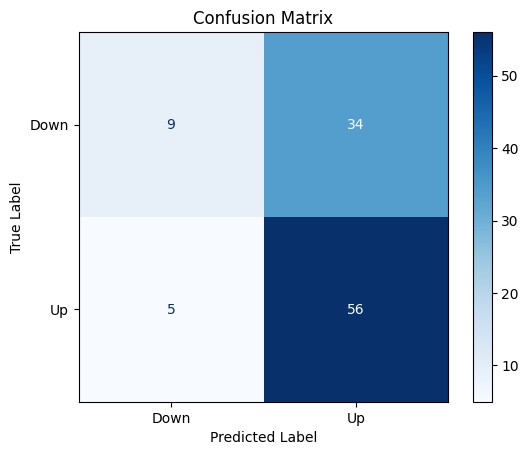

Number of Up Predictions: 90
Number of Down Predictions: 14
Percent Up Predictions: 86.53846153846155
Percent Down Predictions: 13.461538461538462

Accuracy: 0.625


In [59]:
lda = ModelEvaluator('LDA')
lda.fit_model(X,y)
lda.eval_model(novel_X, novel_y, labels)

## Part F

Repeat (d) using QDA.

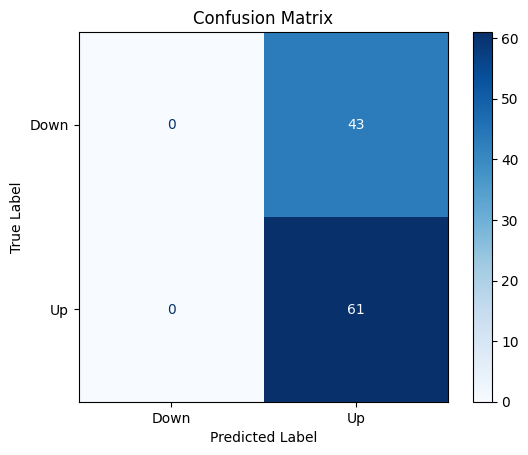

Number of Up Predictions: 104
Number of Down Predictions: 0
Percent Up Predictions: 100.0
Percent Down Predictions: 0.0

Accuracy: 0.5865384615384616


In [60]:
qda = ModelEvaluator('QDA')
qda.fit_model(X,y)
qda.eval_model(novel_X, novel_y, labels)

## Part G

Repeat (d) using KNN with K=1.

Number of neighbors selected: 1


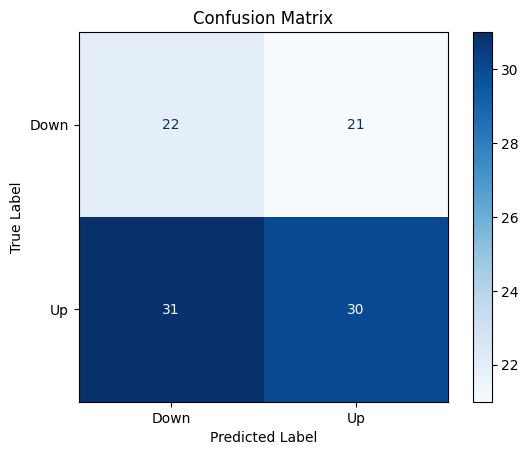

Number of Up Predictions: 51
Number of Down Predictions: 53
Percent Up Predictions: 49.03846153846153
Percent Down Predictions: 50.96153846153846

Accuracy: 0.5


In [61]:
knn = ModelEvaluator('KNN')
knn.fit_model(X,y)
knn.eval_model(novel_X, novel_y, labels)

## Part H

Repeat (d) using naive Bayes.

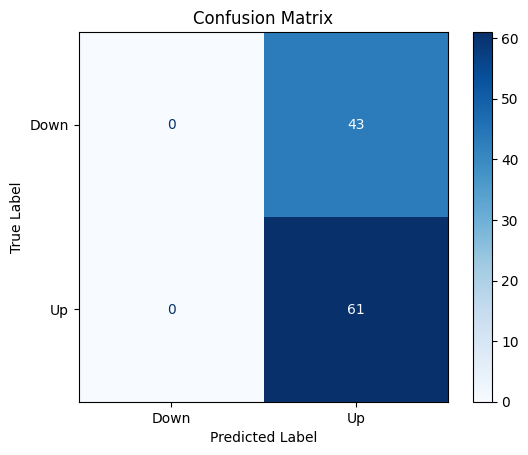

Number of Up Predictions: 104
Number of Down Predictions: 0
Percent Up Predictions: 100.0
Percent Down Predictions: 0.0

Accuracy: 0.5865384615384616


In [62]:
nb = ModelEvaluator('Naive Bayes')
nb.fit_model(X,y)
nb.eval_model(novel_X, novel_y, labels)

**Looks like this model **

## Part I

Which of these methods appears to provide the best results on this data?

In [63]:
models = [logit_model2, lda, qda, knn, nb]

for model in models:
    print(f'{model.name} Accuracy: {model.accuracy}')

Logistic Regression Accuracy: 0.5480769230769231
LDA Accuracy: 0.625
QDA Accuracy: 0.5865384615384616
KNN Accuracy: 0.5
Naive Bayes Accuracy: 0.5865384615384616


**Based on the accuracy metric accross all models, Linear Discriminant Analysis provides the best results. An accuracy of 0.625 is better than random guessing, but too poor to be implemented in a production solution.**

## Part J

Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data. Note that you should also experiment with values for K in the KNN classifier.

**First, I am interested in testing all of the models with additional variables. Year seems like it is critical, as the data is time-dependent.**



Logistic Regression RESULTS: 
         Current function value: 0.000000
         Iterations: 35


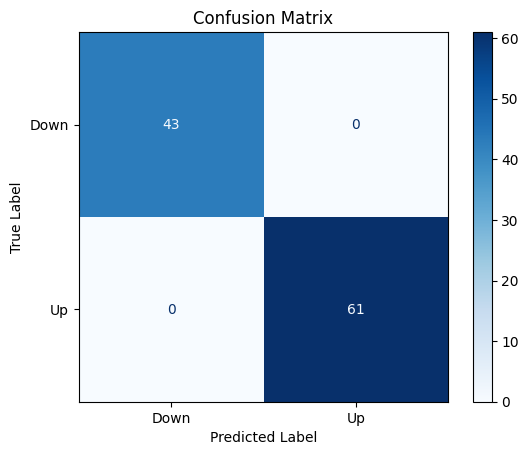

Number of Up Predictions: 61
Number of Down Predictions: 43
Percent Up Predictions: 58.65384615384615
Percent Down Predictions: 41.34615384615385

Accuracy: 1.0


LDA RESULTS: 


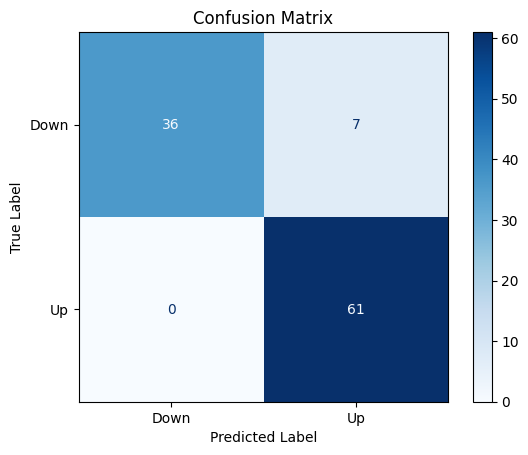

Number of Up Predictions: 68
Number of Down Predictions: 36
Percent Up Predictions: 65.38461538461539
Percent Down Predictions: 34.61538461538461

Accuracy: 0.9326923076923077


QDA RESULTS: 


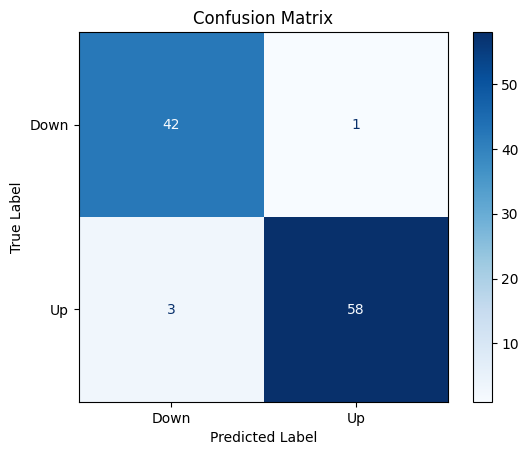

Number of Up Predictions: 59
Number of Down Predictions: 45
Percent Up Predictions: 56.730769230769226
Percent Down Predictions: 43.269230769230774

Accuracy: 0.9615384615384616


KNN RESULTS: 
Number of neighbors selected: 15


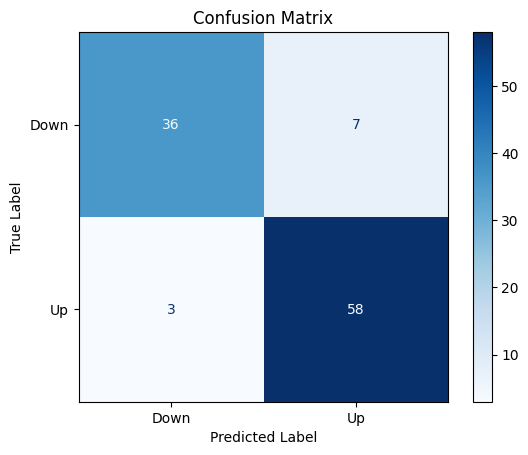

Number of Up Predictions: 65
Number of Down Predictions: 39
Percent Up Predictions: 62.5
Percent Down Predictions: 37.5

Accuracy: 0.9038461538461539


Naive Bayes RESULTS: 


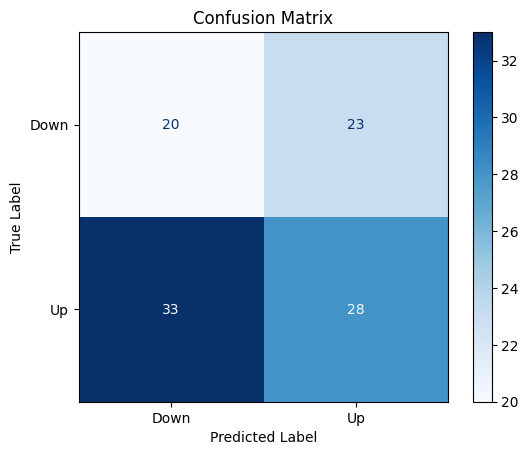

Number of Up Predictions: 51
Number of Down Predictions: 53
Percent Up Predictions: 49.03846153846153
Percent Down Predictions: 50.96153846153846

Accuracy: 0.46153846153846156


In [64]:
X = filtered_weekly[['Volume', 'Year', 'Today', 'Lag2', 'Lag5']].values
y = filtered_weekly[['Direction']]

novel_X = novel_data[['Volume', 'Year', 'Today', 'Lag2', 'Lag5']].values
novel_y = novel_data[['Direction']]

model_names = ['Logistic Regression', 'LDA', 'QDA', 'KNN', 'Naive Bayes']

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)

**This set of predictors produced desireable results with LDA, QDA, and KNN models, each having accuracies greater than 90%. This is a dramatic increase in model performance from the prior models that only used one predictor. The logistic regression model did not converge, and naive bayes produced a poor model accuracy, below 50%.**

**Next, I am interested in trying a square transform on the data. There is some existing non-linearity in the dataset, so I am interested in seeing how this affects each of the models. I will use the same variables for a better comparison.**



Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.685425
         Iterations 4


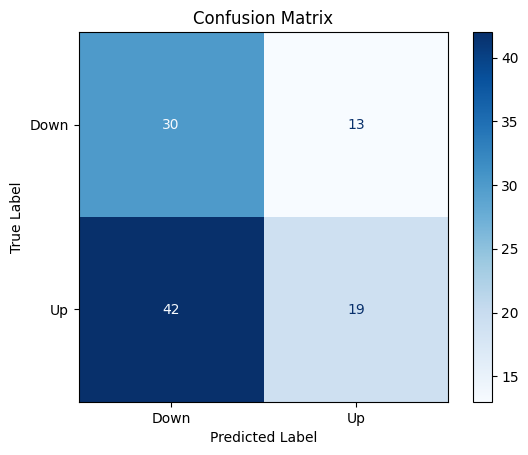

Number of Up Predictions: 32
Number of Down Predictions: 72
Percent Up Predictions: 30.76923076923077
Percent Down Predictions: 69.23076923076923

Accuracy: 0.47115384615384615


LDA RESULTS: 


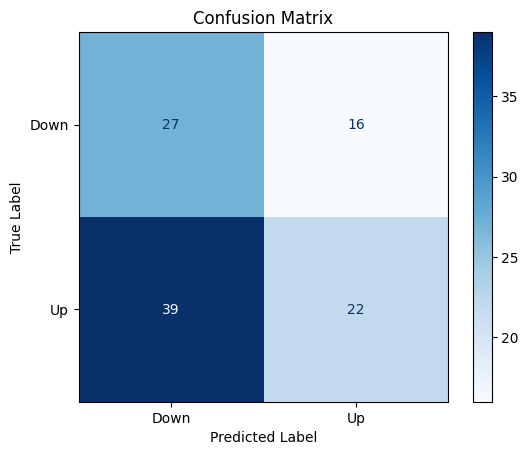

Number of Up Predictions: 38
Number of Down Predictions: 66
Percent Up Predictions: 36.53846153846153
Percent Down Predictions: 63.46153846153846

Accuracy: 0.47115384615384615


QDA RESULTS: 


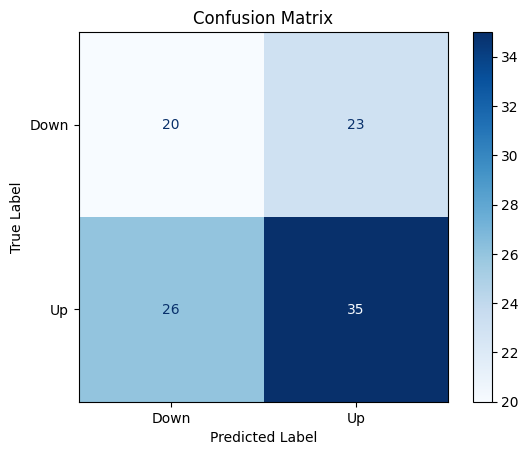

Number of Up Predictions: 58
Number of Down Predictions: 46
Percent Up Predictions: 55.769230769230774
Percent Down Predictions: 44.230769230769226

Accuracy: 0.5288461538461539


KNN RESULTS: 
Number of neighbors selected: 15


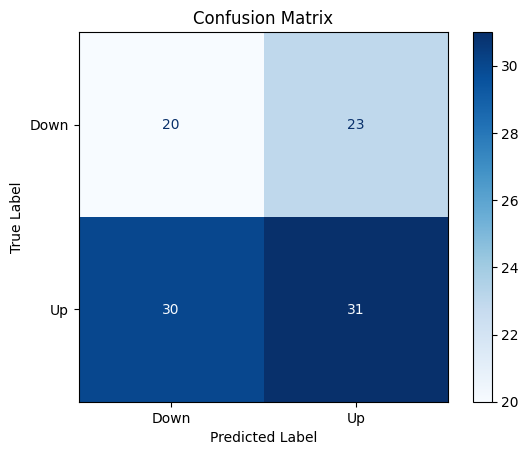

Number of Up Predictions: 54
Number of Down Predictions: 50
Percent Up Predictions: 51.92307692307693
Percent Down Predictions: 48.07692307692308

Accuracy: 0.49038461538461536


Naive Bayes RESULTS: 


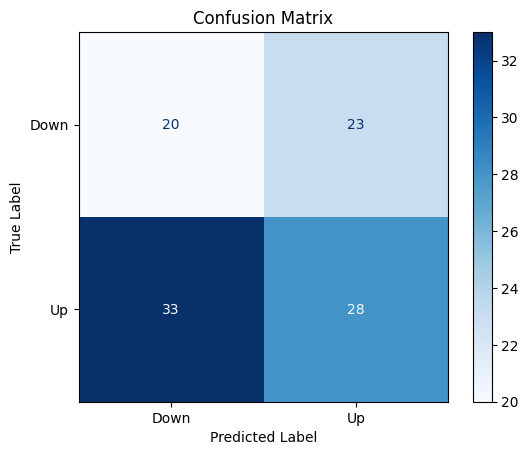

Number of Up Predictions: 51
Number of Down Predictions: 53
Percent Up Predictions: 49.03846153846153
Percent Down Predictions: 50.96153846153846

Accuracy: 0.46153846153846156


In [65]:
sqr_variables = ['Today', 'Lag2', 'Lag5']

test_weekly_df = filtered_weekly.copy()
test_novel_df = novel_data.copy()

for var in sqr_variables:
    test_weekly_df[var] = np.square(filtered_weekly[var])
    test_novel_df[var] = np.square(novel_data[var])

X = test_weekly_df[['Volume', 'Year', 'Today', 'Lag2', 'Lag5']].values
y = test_weekly_df[['Direction']]

novel_X = test_novel_df[['Volume', 'Year', 'Today', 'Lag2', 'Lag5']].values
novel_y = test_novel_df[['Direction']]

model_names = ['Logistic Regression', 'LDA', 'QDA', 'KNN', 'Naive Bayes']

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)

**Okay, that transform eliminated the ability for the model to fit to the data. I expected QDA to be able to fit to this, and, interestingly, it performed the best, but is still nearly randomly guessing.**

**Lastly, I would like to try each of the models with all of the predictors.**



Logistic Regression RESULTS: 
         Current function value: 0.000000
         Iterations: 35


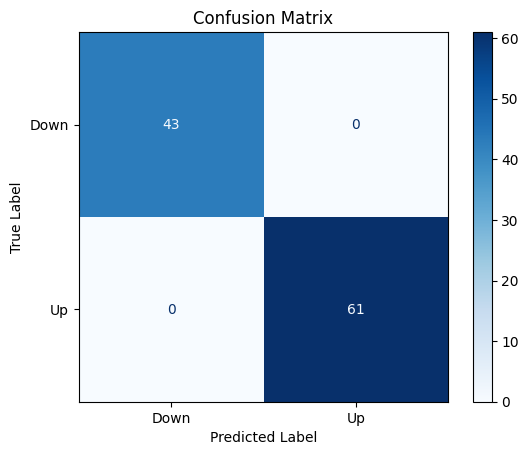

Number of Up Predictions: 61
Number of Down Predictions: 43
Percent Up Predictions: 58.65384615384615
Percent Down Predictions: 41.34615384615385

Accuracy: 1.0


LDA RESULTS: 


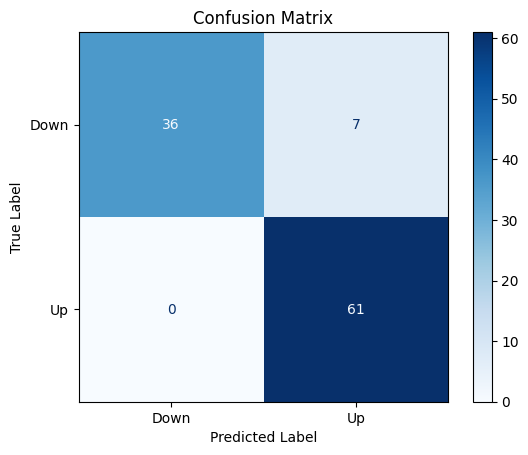

Number of Up Predictions: 68
Number of Down Predictions: 36
Percent Up Predictions: 65.38461538461539
Percent Down Predictions: 34.61538461538461

Accuracy: 0.9326923076923077


QDA RESULTS: 


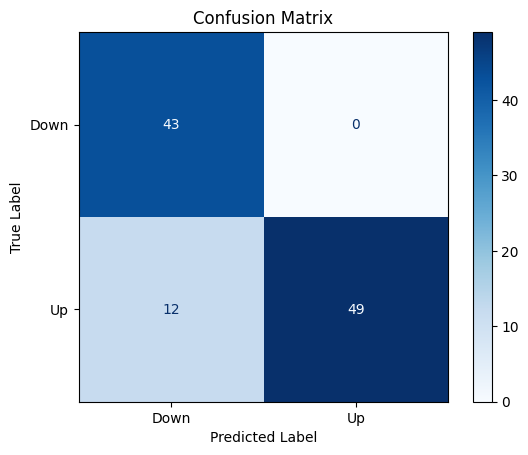

Number of Up Predictions: 49
Number of Down Predictions: 55
Percent Up Predictions: 47.11538461538461
Percent Down Predictions: 52.88461538461539

Accuracy: 0.8846153846153846


KNN RESULTS: 
Number of neighbors selected: 15


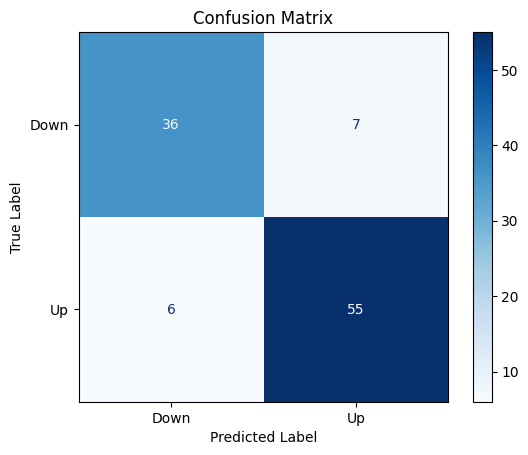

Number of Up Predictions: 62
Number of Down Predictions: 42
Percent Up Predictions: 59.61538461538461
Percent Down Predictions: 40.38461538461539

Accuracy: 0.875


Naive Bayes RESULTS: 


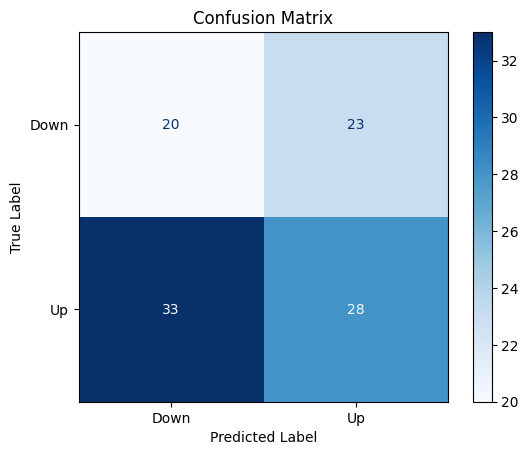

Number of Up Predictions: 51
Number of Down Predictions: 53
Percent Up Predictions: 49.03846153846153
Percent Down Predictions: 50.96153846153846

Accuracy: 0.46153846153846156


In [66]:
X = filtered_weekly[['Volume', 'Year', 'Today', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5']].values
y = filtered_weekly[['Direction']]

novel_X = novel_data[['Volume', 'Year', 'Today', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5']].values
novel_y = novel_data[['Direction']]

model_names = ['Logistic Regression', 'LDA', 'QDA', 'KNN', 'Naive Bayes']

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)

**Interestingly, these models performed worse than the models trained on just 'Volume', 'Year', 'Today', 'Lag2', and 'Lag5'. There are likely higher dimensional interactions present between 'Volume', 'Year', 'Today', 'Lag2', and 'Lag5' that get diluted due to additional interactions with the other lag variables.**

## Problem 16

Using the Boston data set, fit classification models in order to predict whether a given suburb has a crime rate above or below the median. Explore logistic regression, LDA, naive Bayes, and KNN models using various subsets of the predictors. Describe your findings. 

*Hint: You will have to create the response variable yourself, using the variables that are contained in the Boston data set.*


In [67]:
boston = load_data('Boston')
boston.head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [68]:
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [69]:
boston['relative_crime'] = np.where(boston['crim']>boston['crim'].median(), 1, 0)

In [70]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,relative_crime
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,0
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,0
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,0


**There isn't a good variable to use to separate the dataset into train and eval groups, so I will do that randomly based on the row index.**

In [71]:
from random import randint, seed

seed(42)
train_perc = 80
train_indices = []
eval_indices = []

for i in boston.index.values:
    rand_num = randint(1,100)
    if rand_num <= train_perc:
        train_indices.append(i)
    else:
        eval_indices.append(i)

training_data = boston.iloc[train_indices]
eval_data = boston.iloc[eval_indices]

print(len(boston), len(training_data) + len(eval_data))

506 506




Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.407294
         Iterations 7


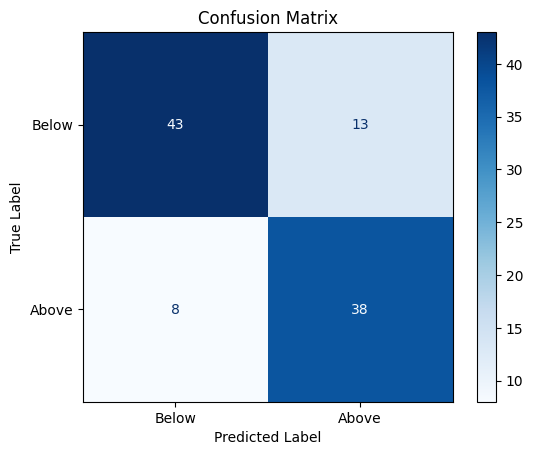

Number of Above Predictions: 51
Number of Below Predictions: 51
Percent Above Predictions: 50.0
Percent Below Predictions: 50.0

Accuracy: 0.7941176470588235


LDA RESULTS: 


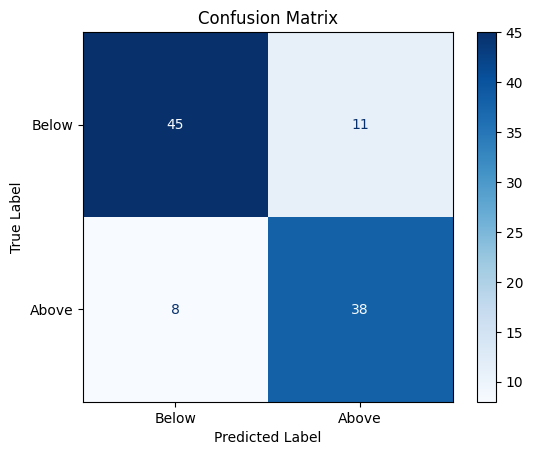

Number of Above Predictions: 49
Number of Below Predictions: 53
Percent Above Predictions: 48.03921568627451
Percent Below Predictions: 51.9607843137255

Accuracy: 0.8137254901960784


QDA RESULTS: 


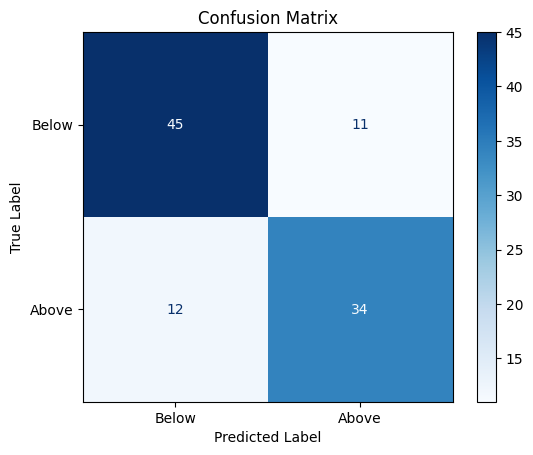

Number of Above Predictions: 45
Number of Below Predictions: 57
Percent Above Predictions: 44.11764705882353
Percent Below Predictions: 55.88235294117647

Accuracy: 0.7745098039215687


KNN RESULTS: 
Number of neighbors selected: 10


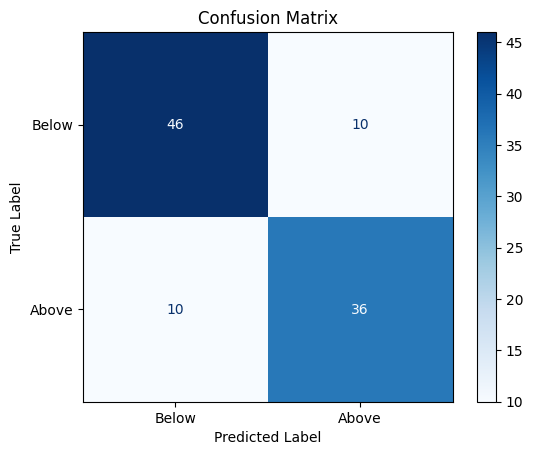

Number of Above Predictions: 46
Number of Below Predictions: 56
Percent Above Predictions: 45.09803921568628
Percent Below Predictions: 54.90196078431373

Accuracy: 0.803921568627451


Naive Bayes RESULTS: 


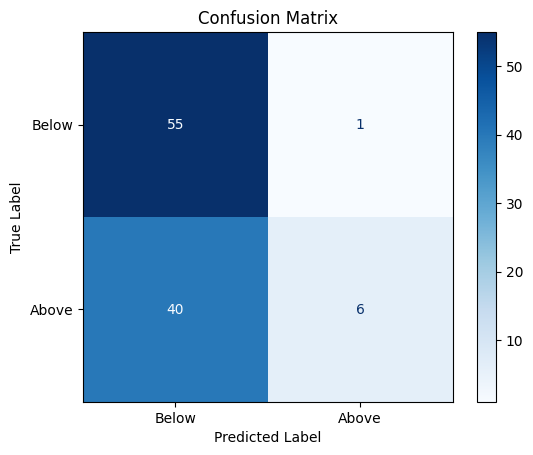

Number of Above Predictions: 7
Number of Below Predictions: 95
Percent Above Predictions: 6.862745098039216
Percent Below Predictions: 93.13725490196079

Accuracy: 0.5980392156862745


In [72]:
training_round_1_variables = ['dis','indus','age','medv','rm']

X = training_data[training_round_1_variables].values
y = training_data[['relative_crime']]

novel_X = eval_data[training_round_1_variables].values
novel_y = eval_data[['relative_crime']]

model_names = ['Logistic Regression', 'LDA', 'QDA', 'KNN', 'Naive Bayes']

labels = ['Below', 'Above']

#This will be used to accumulate the accuracy accross the training rounds for each model
model_results = {name:[] for name in model_names}

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)



Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.376797
         Iterations 8


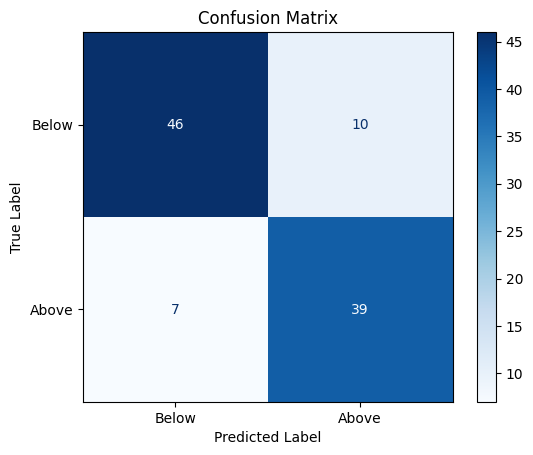

Number of Above Predictions: 49
Number of Below Predictions: 53
Percent Above Predictions: 48.03921568627451
Percent Below Predictions: 51.9607843137255

Accuracy: 0.8333333333333334


LDA RESULTS: 


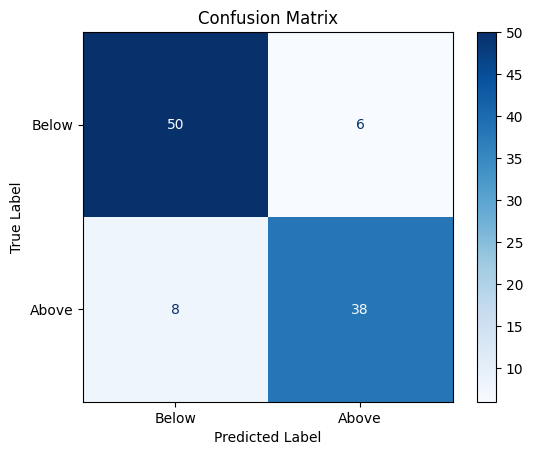

Number of Above Predictions: 44
Number of Below Predictions: 58
Percent Above Predictions: 43.13725490196079
Percent Below Predictions: 56.86274509803921

Accuracy: 0.8627450980392157


QDA RESULTS: 


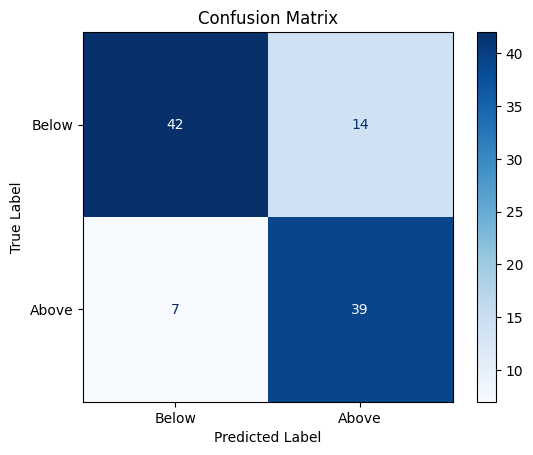

Number of Above Predictions: 53
Number of Below Predictions: 49
Percent Above Predictions: 51.9607843137255
Percent Below Predictions: 48.03921568627451

Accuracy: 0.7941176470588235


KNN RESULTS: 
Number of neighbors selected: 10


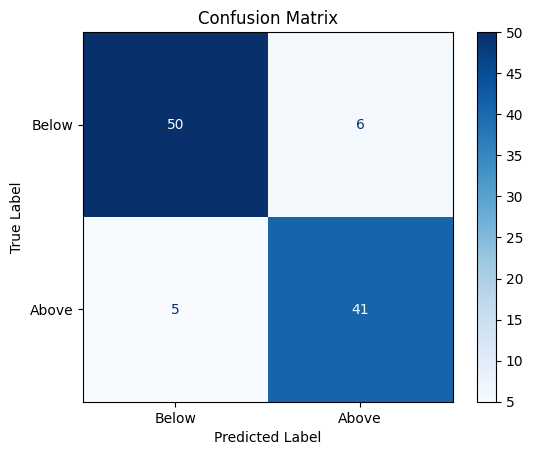

Number of Above Predictions: 47
Number of Below Predictions: 55
Percent Above Predictions: 46.07843137254902
Percent Below Predictions: 53.92156862745098

Accuracy: 0.8921568627450981


Naive Bayes RESULTS: 


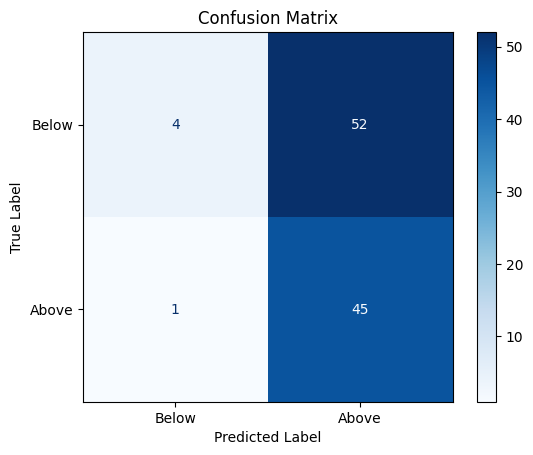

Number of Above Predictions: 97
Number of Below Predictions: 5
Percent Above Predictions: 95.09803921568627
Percent Below Predictions: 4.901960784313726

Accuracy: 0.4803921568627451


In [73]:
training_round_2_variables = ['dis','zn', 'medv','rm','chas', 'tax', 'ptratio']

X = training_data[training_round_2_variables].values
y = training_data[['relative_crime']]

novel_X = eval_data[training_round_2_variables].values
novel_y = eval_data[['relative_crime']]

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)



Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.512183
         Iterations 7


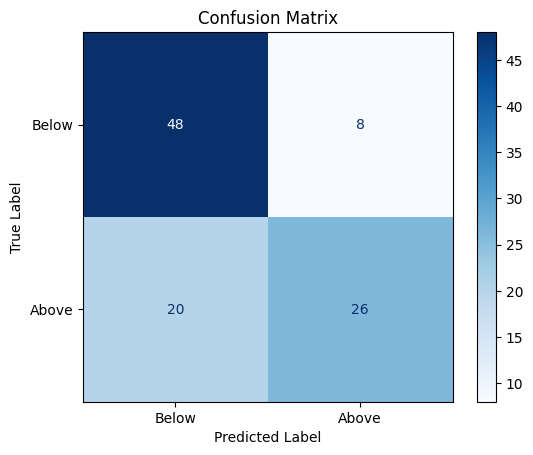

Number of Above Predictions: 34
Number of Below Predictions: 68
Percent Above Predictions: 33.33333333333333
Percent Below Predictions: 66.66666666666666

Accuracy: 0.7254901960784313


LDA RESULTS: 


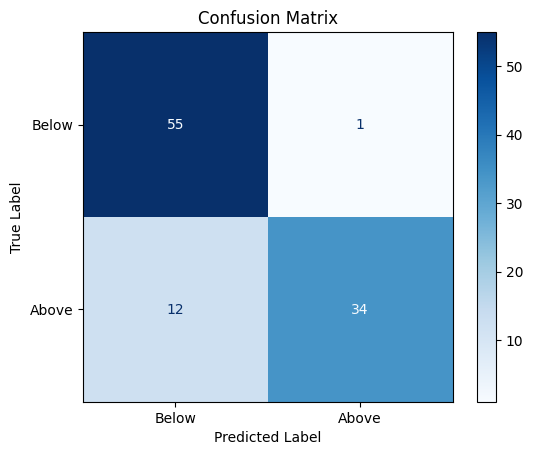

Number of Above Predictions: 35
Number of Below Predictions: 67
Percent Above Predictions: 34.31372549019608
Percent Below Predictions: 65.68627450980392

Accuracy: 0.8725490196078431


QDA RESULTS: 


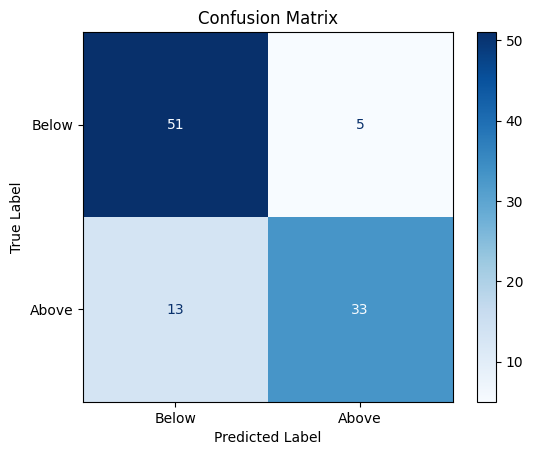

Number of Above Predictions: 38
Number of Below Predictions: 64
Percent Above Predictions: 37.254901960784316
Percent Below Predictions: 62.745098039215684

Accuracy: 0.8235294117647058


KNN RESULTS: 
Number of neighbors selected: 10


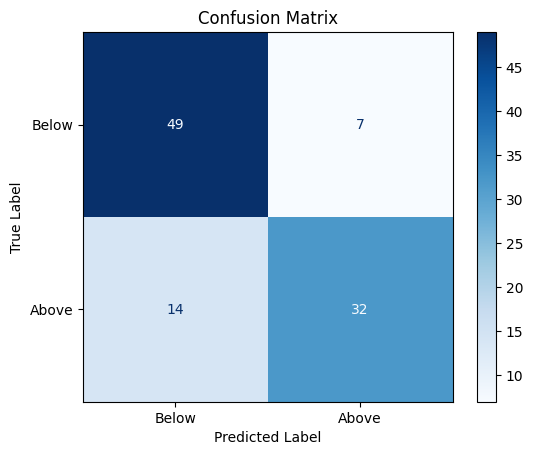

Number of Above Predictions: 39
Number of Below Predictions: 63
Percent Above Predictions: 38.23529411764706
Percent Below Predictions: 61.76470588235294

Accuracy: 0.7941176470588235


Naive Bayes RESULTS: 


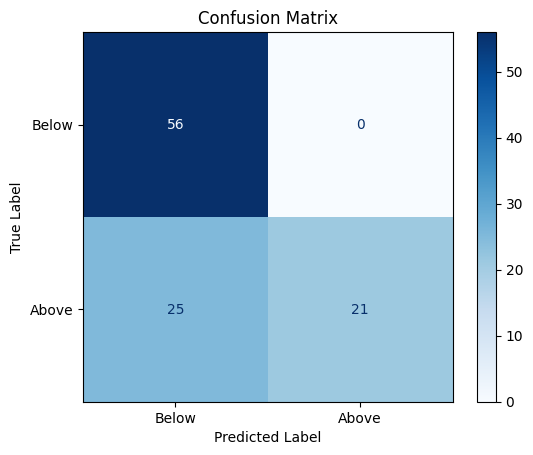

Number of Above Predictions: 21
Number of Below Predictions: 81
Percent Above Predictions: 20.588235294117645
Percent Below Predictions: 79.41176470588235

Accuracy: 0.7549019607843137


In [74]:
training_round_3_variables = ['nox', 'chas', 'lstat', 'rad']

X = training_data[training_round_3_variables].values
y = training_data[['relative_crime']]

novel_X = eval_data[training_round_3_variables].values
novel_y = eval_data[['relative_crime']]

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)



Logistic Regression RESULTS: 
Optimization terminated successfully.
         Current function value: 0.278465
         Iterations 10


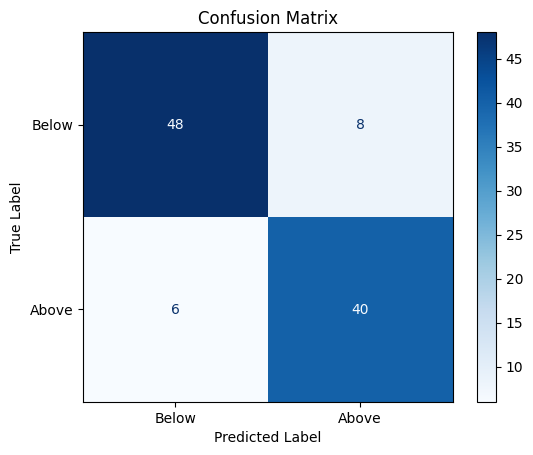

Number of Above Predictions: 48
Number of Below Predictions: 54
Percent Above Predictions: 47.05882352941176
Percent Below Predictions: 52.94117647058824

Accuracy: 0.8627450980392157


LDA RESULTS: 


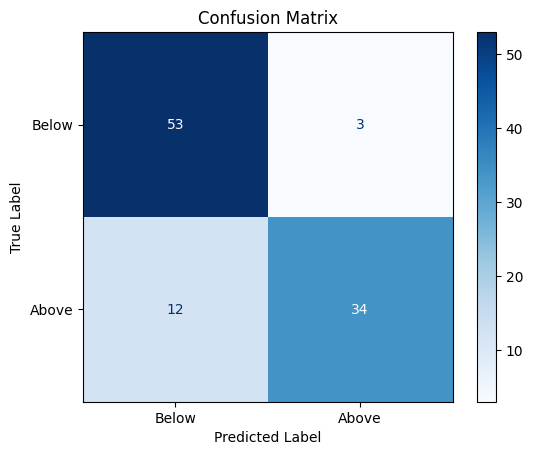

Number of Above Predictions: 37
Number of Below Predictions: 65
Percent Above Predictions: 36.27450980392157
Percent Below Predictions: 63.725490196078425

Accuracy: 0.8529411764705882


QDA RESULTS: 


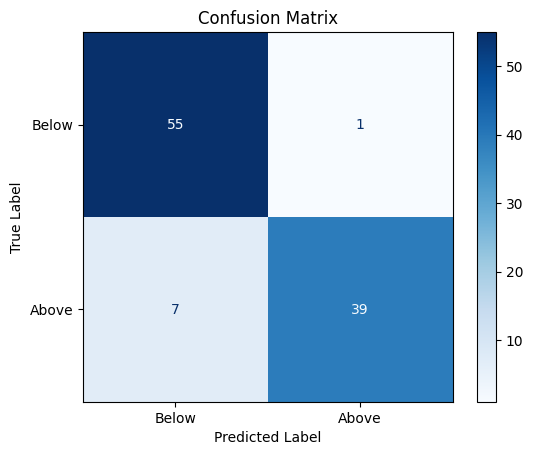

Number of Above Predictions: 40
Number of Below Predictions: 62
Percent Above Predictions: 39.21568627450981
Percent Below Predictions: 60.78431372549019

Accuracy: 0.9215686274509803


KNN RESULTS: 
Number of neighbors selected: 10


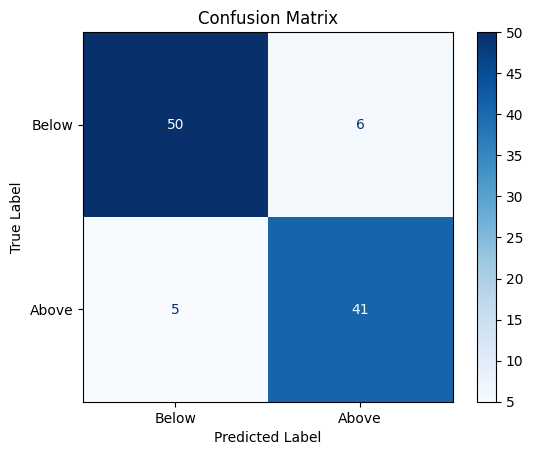

Number of Above Predictions: 47
Number of Below Predictions: 55
Percent Above Predictions: 46.07843137254902
Percent Below Predictions: 53.92156862745098

Accuracy: 0.8921568627450981


Naive Bayes RESULTS: 


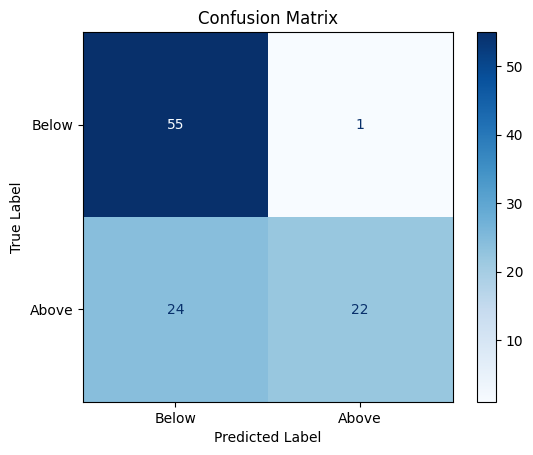

Number of Above Predictions: 23
Number of Below Predictions: 79
Percent Above Predictions: 22.54901960784314
Percent Below Predictions: 77.45098039215686

Accuracy: 0.7549019607843137


In [75]:
training_round_4_variables = boston.columns.drop(['crim', 'relative_crime']).values

X = training_data[training_round_4_variables].values
y = training_data[['relative_crime']]

novel_X = eval_data[training_round_4_variables].values
novel_y = eval_data[['relative_crime']]

for model in model_names:
    print(f'\n\n{model} RESULTS: ')
    test_model = ModelEvaluator(model)
    test_model.fit_model(X, y)
    test_model.eval_model(novel_X, novel_y, labels)
    model_results[model].append(test_model.accuracy)

**Now, lets evaluate the scores across all models and variable sets.**

In [76]:
for model, result in model_results.items():
    print(model, result)

Logistic Regression [0.7941176470588235, 0.8333333333333334, 0.7254901960784313, 0.8627450980392157]
LDA [0.8137254901960784, 0.8627450980392157, 0.8725490196078431, 0.8529411764705882]
QDA [0.7745098039215687, 0.7941176470588235, 0.8235294117647058, 0.9215686274509803]
KNN [0.803921568627451, 0.8921568627450981, 0.7941176470588235, 0.8921568627450981]
Naive Bayes [0.5980392156862745, 0.4803921568627451, 0.7549019607843137, 0.7549019607843137]


**Based on the results from the different model/predictor combinations, the most accurate model and predictor combination was QDA with all predictors in the dataset, aside from crime. To my surprise, training round 3 produced models with accurate predictions using variables that seemed entirely independent of crime rate ('nox', 'chas', 'lstat', 'rad'). I suspect this is because these variables are related to geographical location, which is a predictor for crime rates.**